# Binarize vs Quantize on a Simple Binary Deflector

This notebook compares two ways of mapping a continuous deflector phase profile to discrete values:

- `binarize`: threshold-based mapping to `{0, \pi}`
- `quantize(..., 2)`: nearest-level mapping to `{0, \pi}`

The same deflector phase ramp is used for both, so the difference comes only from the discretization rule.

If you want `quantize` to behave more like `binarize` when `n_levels = 2`, the simplest change is to threshold the wrapped phase at zero instead of using half-step rounding.

In [32]:
# 1. Import Required Libraries
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start: Path) -> Path:
    """Walk upward until the lib4lum package is found."""
    for candidate in [start, *start.parents]:
        if (candidate / 'lib4lum' / 'phase_profiles.py').exists():
            return candidate
    raise FileNotFoundError('Could not locate lib4lum/phase_profiles.py')


ROOT = find_repo_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lib4lum.phase_profiles import binarize, deflector_profile, quantize

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)

In [33]:
# 2. Define Binary Deflector Class
class BinaryDeflector:
    """Small wrapper around the existing phase-profile helpers."""

    def __init__(self, wavelength: float, period: float, size: int):
        self.wavelength = wavelength
        self.period = period
        self.size = size

    def phase_map(self, theta_x: float, theta_y: float = 0.0) -> np.ndarray:
        return deflector_profile(theta_x, theta_y, self.wavelength, self.period, self.size)

    def binarize_phase(self, phase: np.ndarray) -> np.ndarray:
        return binarize(phase)

    def quantize_phase(self, phase: np.ndarray, n_levels: int) -> np.ndarray:
        return quantize(phase, n_levels)

    @staticmethod
    def center_line(array: np.ndarray) -> np.ndarray:
        return array[array.shape[0] // 2]


WL = 850e-9
PERIOD = 425e-9
SIZE = 18
THETA_X = np.deg2rad(12.0)
THETA_Y = 0.0


deflector = BinaryDeflector(wavelength=WL, period=PERIOD, size=SIZE)
phase = deflector.phase_map(THETA_X, THETA_Y)
center_index = phase.shape[0] // 2
x_axis_um = (np.arange(phase.shape[1]) - center_index) * PERIOD * 1e6

In [34]:
# 3. Demonstrate Binarization
phase_binary = deflector.binarize_phase(phase-np.pi/2)
phase_quantized_2 = deflector.quantize_phase(phase, n_levels=2)

print('Binary output values:', np.unique(phase_binary))
print('Quantized-2 output values:', np.unique(phase_quantized_2))
print('\nCentral row of raw phase (radians):')
print(np.round(deflector.center_line(phase), 3))
print('\nCentral row after binarize (0 or pi):')
print(np.round(deflector.center_line(phase_binary), 3))
print('\nCentral row after quantize(phase, 2):')
print(np.round(deflector.center_line(phase_quantized_2), 3))

Binary output values: [0.    3.142]
Quantized-2 output values: [0.    3.142]

Central row of raw phase (radians):
[ 11.757  11.104  10.451   9.798   9.144   8.491   7.838   7.185   6.532
   5.879   5.225   4.572   3.919   3.266   2.613   1.96    1.306   0.653
  -0.     -0.653  -1.306  -1.96   -2.613  -3.266  -3.919  -4.572  -5.225
  -5.879  -6.532  -7.185  -7.838  -8.491  -9.144  -9.798 -10.451 -11.104
 -11.757]

Central row after binarize (0 or pi):
[0.    0.    3.142 3.142 3.142 3.142 0.    0.    0.    0.    0.    3.142
 3.142 3.142 3.142 3.142 0.    0.    0.    0.    0.    3.142 3.142 3.142
 3.142 3.142 0.    0.    0.    0.    0.    3.142 3.142 3.142 3.142 0.
 0.   ]

Central row after quantize(phase, 2):
[0.    0.    3.142 3.142 3.142 3.142 0.    0.    0.    0.    0.    3.142
 3.142 3.142 3.142 3.142 0.    0.    0.    0.    0.    3.142 3.142 3.142
 3.142 3.142 0.    0.    0.    0.    0.    3.142 3.142 3.142 3.142 0.
 0.   ]


In [35]:
# 5. Compare Results Side-by-Side
sample_phases = np.array([
    -np.pi,
    -0.75 * np.pi,
    -0.25 * np.pi,
    0.0,
    0.25 * np.pi,
    0.75 * np.pi,
    np.pi,
])

sample_binarized = binarize(sample_phases)
sample_quantized_2 = quantize(sample_phases, 2)

print(f"{'input':>10} | {'binarize':>10} | {'quantize(2)':>11}")
print('-' * 36)
for raw, b, q2 in zip(sample_phases, sample_binarized, sample_quantized_2):
    print(f"{raw/np.pi:9.2f}π | {b/np.pi:9.2f}π | {q2/np.pi:10.2f}π")

print('\nTo make quantize behave like binarize for n_levels = 2:')
print('  wrap the phase to (-pi, pi] and threshold at zero, instead of half-step rounding.')
print('  Example rule: return pi when wrapped_phase >= 0, else 0.')

     input |   binarize | quantize(2)
------------------------------------
    -1.00π |      0.00π |       1.00π
    -0.75π |      0.00π |       1.00π
    -0.25π |      0.00π |       0.00π
     0.00π |      1.00π |       0.00π
     0.25π |      1.00π |       0.00π
     0.75π |      1.00π |       1.00π
     1.00π |      1.00π |       1.00π

To make quantize behave like binarize for n_levels = 2:
  wrap the phase to (-pi, pi] and threshold at zero, instead of half-step rounding.
  Example rule: return pi when wrapped_phase >= 0, else 0.


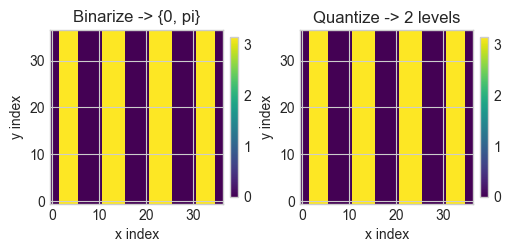

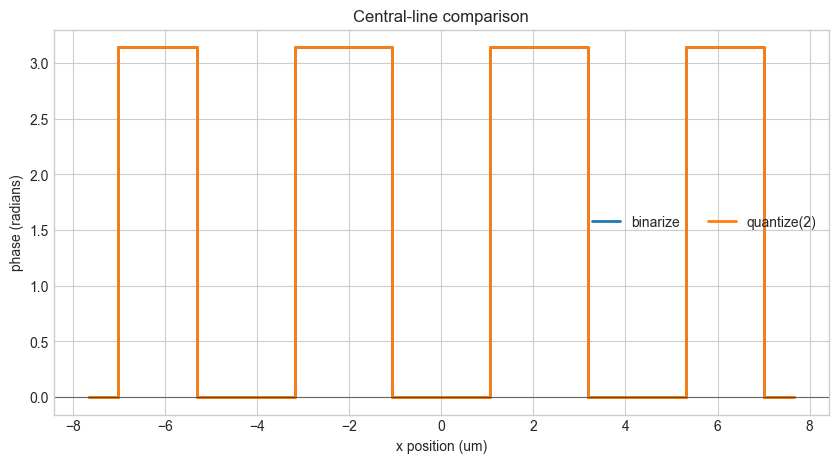

In [36]:
# 6. Visualize Differences
fig, axes = plt.subplots(1,2, figsize=(5, 10), constrained_layout=True)

plots = [
    (phase_binary, 'Binarize -> {0, pi}', 'viridis'),
    (phase_quantized_2, 'Quantize -> 2 levels', 'viridis'),
]

for ax, (data, title, cmap) in zip(axes.flat, plots):
    image = ax.imshow(data, origin='lower', cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel('x index')
    ax.set_ylabel('y index')
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

for ax in axes.flat[len(plots):]:
    ax.axis('off')

plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.step(x_axis_um, deflector.center_line(phase_binary), where='mid', label='binarize', linewidth=2)
ax.step(x_axis_um, deflector.center_line(phase_quantized_2), where='mid', label='quantize(2)', linewidth=2)
ax.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
ax.set_xlabel('x position (um)')
ax.set_ylabel('phase (radians)')
ax.set_title('Central-line comparison')
ax.legend(ncol=2)
plt.show()

## binarize(phase-$\pi/2$) $\sim$ quantize(phase, n=2)